In [6]:
# Load Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

# See the Problem
df[["monthly_income", "monthly_bill"]].describe()


,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


In [7]:
df["income_log"] = np.log1p(df["monthly_income"])

df[["monthly_income", "income_log"]].head()


,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


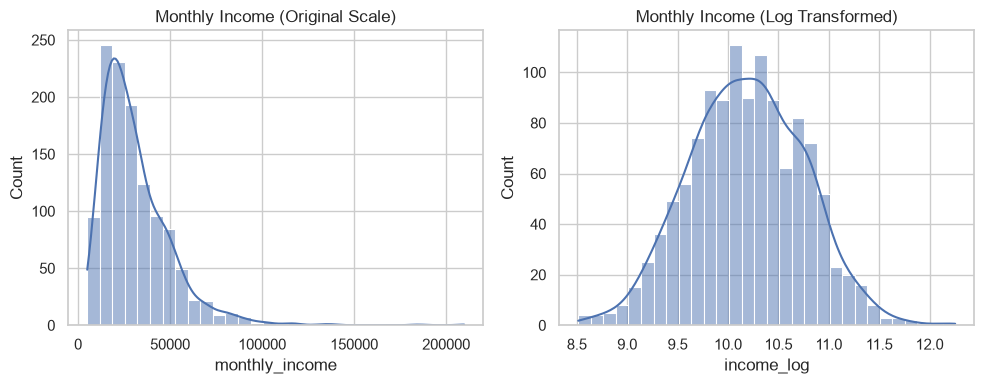

In [8]:

sns.set(style="whitegrid")

plt.figure(figsize=(10,4))

plt.subplot(1, 2,1)
sns.histplot(df["monthly_income"], kde=True, bins=30)
plt.title("Monthly Income (Original Scale)")

plt.subplot(1, 2, 2)
sns.histplot(df["income_log"], kde=True, bins=30)
plt.title("Monthly Income (Log Transformed)")

plt.tight_layout()
plt.show()

In [9]:
# Before vs After
df[["monthly_income", "income_log"]].describe()


,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


In [10]:

# Clipping
upper_limit = df["monthly_bill"].quantile(0.99)

df["bill_clipped"] =df["monthly_bill"].clip(upper=upper_limit)

df.loc[
[df["monthly_bill"].idxmax(),
df["monthly_bill"].sort_values().index[len(df)//2]],
["monthly_bill", "bill_clipped"] ]

,monthly_bill,bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


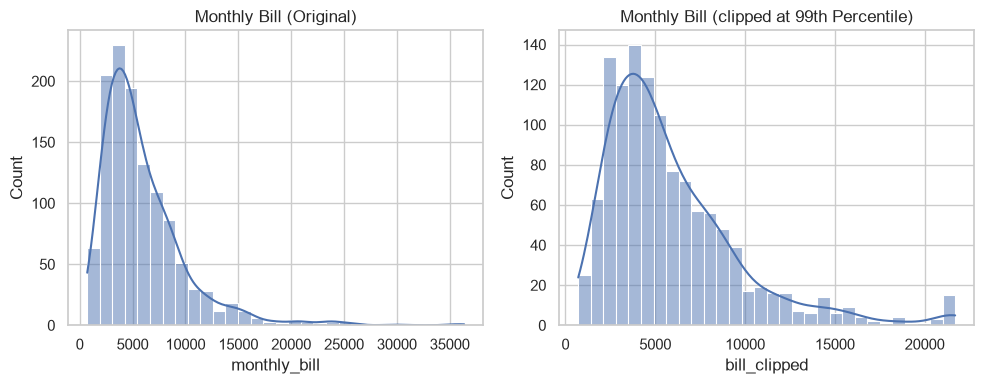

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
sns.histplot(df["monthly_bill"], kde=True, bins=30)
plt.title("Monthly Bill (Original)")

plt.subplot(1, 2, 2)
sns.histplot(df["bill_clipped"], kde=True, bins=30)
plt.title("Monthly Bill (clipped at 99th Percentile)")

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats.mstats import winsorize

# Winsorize: cap only the top 10%
df["bill_winsor"] = winsorize(
df["monthly_bill"],
limits=[0.01, 0.01]
)


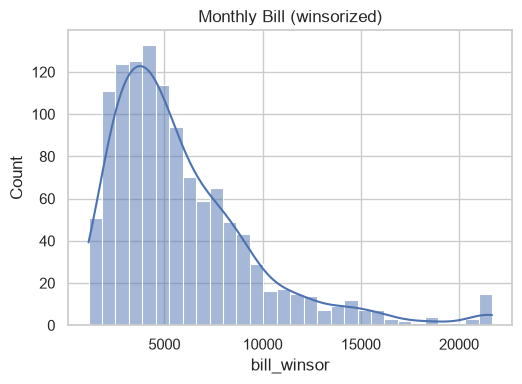

In [14]:

# [Lower_cap, upper_cap]

# Check effect on extreme values
df.loc[

[df["monthly_bill"].idxmin(),
df["monthly_bill"].idxmax()],
["bill_winsor"]
]

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 2)
sns.histplot(df["bill_winsor"], kde=True, bins=30)
plt.title("Monthly Bill (winsorized)")

plt.tight_layout()
plt.show()